                                                  XGB Classifier with Morphological features

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Data 
df = pd.read_csv(r"C:\Users\PIYUSH\Downloads\MyTable_1_TwinkleKashyap.csv")

In [3]:
df[['psf_model_diff_r', 'petro_exp_ratio_r']].describe()

,psf_model_diff_r,petro_exp_ratio_r
count,100000.000000,1.000000e+05
mean,0.680181,1.130912e+04
std,0.718879,4.358272e+05
min,-6.364922,7.615927e-03
25%,0.011695,2.726260e+00
50%,0.584153,4.192400e+00
75%,1.136556,1.489911e+01
max,7.447768,6.817986e+07


In [4]:

df.drop('objid', axis=1, inplace=True)


# Feature Engineering 
df['u_g'] = df['u'] - df['g']
df['g_r'] = df['g'] - df['r']
df['r_i'] = df['r'] - df['i']
df['i_z'] = df['i'] - df['z']

#Cleaning
df = df[(df['u_g'] > -5) & (df['u_g'] < 5) &
        (df['g_r'] > -5) & (df['g_r'] < 5)]



In [5]:
# Encode Labels 
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

# Features & Target -
X = df.drop('class', axis=1)
y = df['class']

feature_names = X.columns
#  Train-Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [6]:
#  XGBoost Model 
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [7]:
#  Predictions 
y_pred = xgb.predict(X_test)


In [8]:
#  Evaluation 
print("WITH REDSHIFT")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

WITH REDSHIFT
Accuracy: 0.9838628510081524
[[16797   124    76]
 [  268  3817     0]
 [   13     0  8712]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     16997
           1       0.97      0.93      0.95      4085
           2       0.99      1.00      0.99      8725

    accuracy                           0.98     29807
   macro avg       0.98      0.97      0.98     29807
weighted avg       0.98      0.98      0.98     29807



In [9]:
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',linewidths=0.5, linecolor='black')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

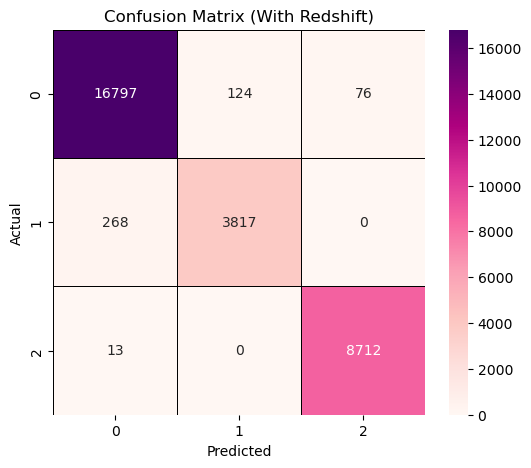

In [10]:
plot_conf_matrix(y_test, y_pred, "Confusion Matrix (With Redshift)")

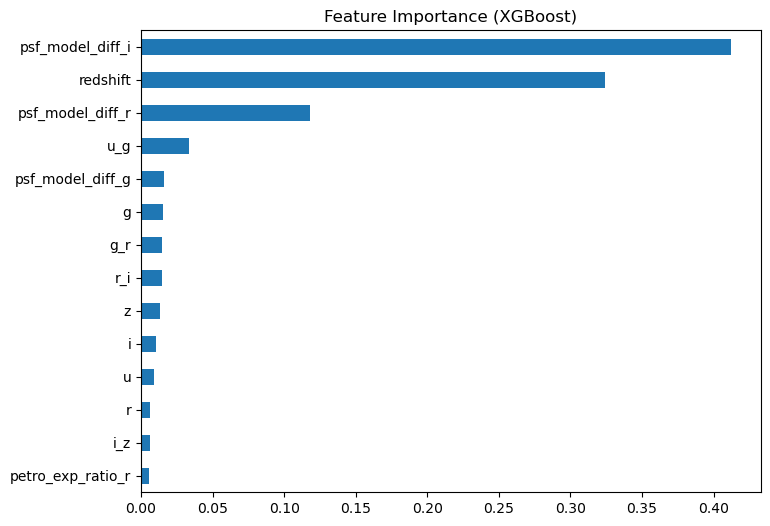

In [11]:
import seaborn as sns

feat_imp = pd.Series(xgb.feature_importances_, index=feature_names)
feat_imp = feat_imp.sort_values()

plt.figure(figsize=(8,6))
feat_imp.plot(kind='barh')
plt.title("Feature Importance (XGBoost)")
plt.show()

                                                         Without Redshift

In [12]:
# Drop redshift
X_no_z = X.drop('redshift', axis=1)

feature_names = list(feature_names)
feature_names.remove('redshift')

X_train, X_test, y_train, y_test = train_test_split(
    X_no_z, y, test_size=0.3, random_state=42
)

In [13]:
#  XGBoost Model 
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [14]:
y_pred = xgb.predict(X_test)

In [15]:
print("\nWITHOUT REDSHIFT")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


WITHOUT REDSHIFT
Accuracy: 0.9293454557654243
[[16561   201   235]
 [  336  3081   668]
 [  237   429  8059]]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     16997
           1       0.83      0.75      0.79      4085
           2       0.90      0.92      0.91      8725

    accuracy                           0.93     29807
   macro avg       0.90      0.88      0.89     29807
weighted avg       0.93      0.93      0.93     29807



In [16]:
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='PuRd',linewidths=0.5, linecolor='black')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

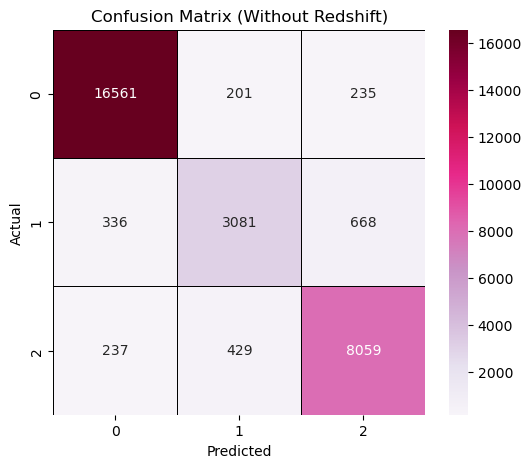

In [17]:
plot_conf_matrix(y_test, y_pred, "Confusion Matrix (Without Redshift)")

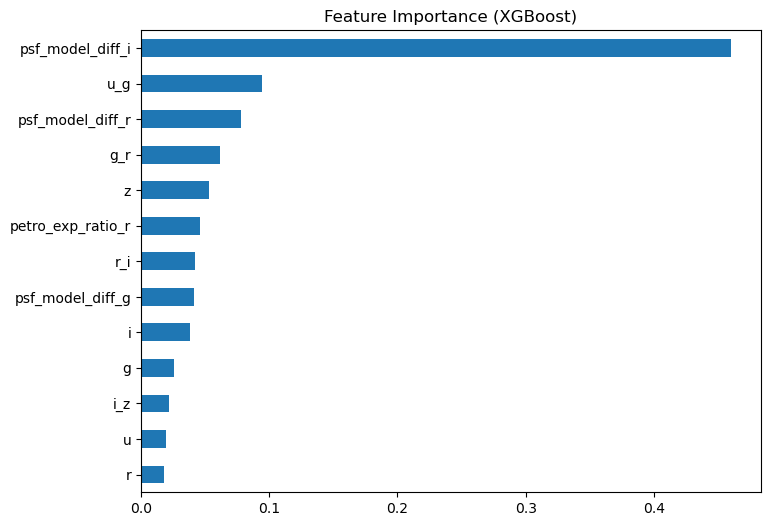

In [18]:
feat_imp = pd.Series(xgb.feature_importances_, index=feature_names)
feat_imp = feat_imp.sort_values()

plt.figure(figsize=(8,6))
feat_imp.plot(kind='barh')
plt.title("Feature Importance (XGBoost)")
plt.show()

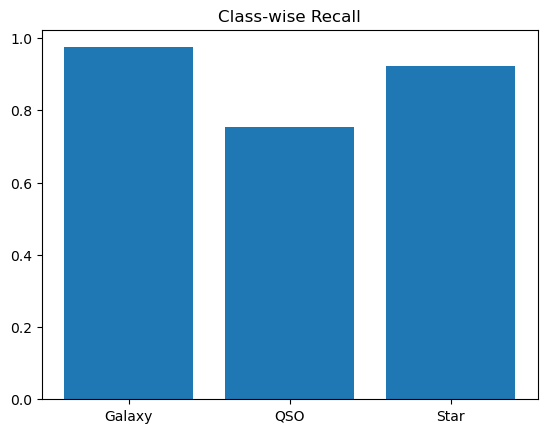

In [19]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, output_dict=True)

recalls = [report[str(i)]['recall'] for i in range(3)]

plt.bar(['Galaxy','QSO','Star'], recalls)
plt.title("Class-wise Recall")
plt.show()
